### Example analysis workflow for ACCESS-EMS-GBR model output


In [1]:
import xarray as xr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import cmocean
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import geopandas as gpd
import regionmask
import xesmf as xe
import pandas as pd
from tabulate import tabulate
from scipy import stats

### Functions

In [2]:
'''
Plot maps (time mean)
---------------------
data_2d : 2D data to plot
lats    : latitude coords (latitude or y_centre)
lons    : longitude coords (longitude or x_centre)
cmap    : colour map to use
plt_log : True to use log scale
'''
def plot_map(data_2d, lats, lons, cmap, plt_log):

    # Plot settings
    plt.rcParams.update({'font.size': 14})
    plt_height = 6
    plt_width = 6
    fig = plt.figure(figsize=(plt_width,plt_height))
    if plt_log:
        cNorm = colors.LogNorm(vmin=np.nanmin(data_2d), vmax=np.nanmax(data_2d))
    else:
        cNorm = colors.Normalize(vmin=np.nanmin(data_2d), vmax=np.nanmax(data_2d))
    try:
        plt_label = data_2d.name+' ('+data_2d.units+')'
    except:
        plt_label = ' '
    
    # Plot data
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    ax_plt = ax.pcolor(lons, lats, data_2d, cmap=cmap, norm=cNorm)

    # Add features
    im_ratio = plt_height/plt_width
    plt.colorbar(ax_plt, fraction=0.046*im_ratio, orientation='vertical').set_label(label=plt_label)
    ax.coastlines('10m')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, color='black', linewidth=0.5, alpha=0.3)
    gl.left_labels = True
    gl.bottom_labels = True 


'''
Plot time-series
----------------
data_1d = 1D data to plot (area mean or single gridbox)
'''
def plot_tseries(data_1d):

    # Plot settings
    plt.rcParams.update({'font.size': 14})
    date_form = DateFormatter("%d-%m-%y")
    plt_line = {'linestyle':'-', 'color':'C0', 'linewidth':1.5} 
    try:
        plt_label = data_1d.name+' ('+data_1d.units+')'
    except:
        plt_label = ' '
        
    # Plot data
    fig = plt.figure(figsize=(15,4))
    ax = fig.add_subplot(111)
    ax.plot(data_1d.time, data_1d, **plt_line)
    ax.set(ylabel = plt_label)  
    ax.xaxis.set_major_formatter(date_form)
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=(2,24))) # assuming output starts at 00:00 UTC
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
    ax.set(xlabel = 'Date (noon UTC+10)');


'''
Get data for a given coordinate
-------------------------------
ds      : xarray dataset w. model output
lat/lon : required lat/lon
method  : 'linear' or 'nearest' (GBR4 output is always nearest)
'''
def get_model4coord(ds, lat, lon, method):
    if ('latitude' in ds.dims) or ('latitude_0' in ds.dims): # UM regular grid
        out_ds = ds.interp(latitude=lat, latitude_0=lat, longitude=lon, longitude_0=lon, method=method)

    elif 'j_centre' in ds.dims: # eReefs curvilinear grid
        abslat = np.abs(ds.y_centre - lat)
        abslon = np.abs(ds.x_centre - lon)
        c = np.maximum(abslon, abslat)
        ([yloc], [xloc]) = np.where(c == np.min(c))
        out_ds = ds.copy().isel(j_centre=yloc, i_centre=xloc)
    
    return out_ds


'''
Summary statistics
------------------
ds = xarray dataset w. model output
ds_vars = list of variables to cal summary stats
'''
def sum_stats(ds, ds_vars):
    table = [['Variable', 'No. points', 'Mean', 'Min', 'Max', 'SD']]
    for ivar in ds_vars:
        try:
            var_label = ivar+' ('+ds[ivar].units+')'
        except:
            var_label = ivar
        summary = stats.describe(ds[ivar], nan_policy='omit')
        table.append([var_label, summary[0], summary[2], summary[1][0], summary[1][1], summary[3]])
    print(tabulate(table, headers='firstrow', tablefmt='fancy_grid'))

### Read in model output

In [3]:
suite = 'de207'
out_dir = '/g/data/p66/rj9627/UM_NS/output/RRAP/ACCESS-EMS-GBR/u-'+suite+'/'
start_dt = dt.datetime(2022,1,1)
end_dt = dt.datetime(2022,4,30)

# Atmosphere
rgn = 'NE_Aus'
res = '4km'
fcst = 48
lev_height = 5 # m
aod_level = 2 # 550 nm
atmos_ds = xr.open_mfdataset(out_dir+'/um2nc/'+suite+'-'+rgn+'-'+res+'-'+str(fcst)+'hrFcst-*', concat_dim='time', combine='nested', data_vars='different')
atmos_ds = atmos_ds.sel(time=slice(start_dt,end_dt), level_height=lev_height, level_height_0=slice(0,lev_height*3), pseudo_level=aod_level) # Subset by time & level
atmos_ds = atmos_ds.interp(level_height_0=lev_height) # Put winds on the same level
atmos_ds = atmos_ds.isel(latitude=slice(10,-11), latitude_0=slice(10,-11), longitude=slice(10,-11), longitude_0=slice(10,-11)) # Exclude edge effects

# Ocean
lev_depth = -5.55 # m
ocean_ds = xr.open_mfdataset(out_dir+'/gbr4_bgc/gbr4_bgc_all*', concat_dim='record', combine='nested', data_vars='different')
ocean_ds = ocean_ds.swap_dims({'k_centre':'z_centre'}) # Swap model level number for depth
ocean_ds = ocean_ds.sel(z_centre=lev_depth) # Subset level
ocean_ds = ocean_ds.swap_dims({'record':'t'}) # Swap record index for time stamps
ocean_ds = ocean_ds.assign_coords(t = pd.to_datetime(ocean_ds.t).round('h'))
ocean_ds = ocean_ds.rename({'t':'time'})
ocean_ds = ocean_ds.sel(time=slice(start_dt,end_dt)) # Subset by time

In [4]:
display(atmos_ds)

<xarray.Dataset> Size: 110GB
Dimensions:                  (latitude: 604, longitude_0: 529, time: 696,
                              longitude: 529, latitude_0: 605)
Coordinates: (12/14)
  * latitude                 (latitude) float32 2kB -30.6 -30.56 ... -6.52 -6.48
  * longitude_0              (longitude_0) float32 2kB 141.4 141.4 ... 162.5
    forecast_reference_time  (time) datetime64[ns] 6kB 2022-01-31 ... 2022-02-28
    sigma_0                  float64 8B dask.array<chunksize=(), meta=np.ndarray>
  * time                     (time) datetime64[ns] 6kB 2022-02-01 ... 2022-03...
    level_height             float64 8B 5.0
    ...                       ...
    pseudo_level             int64 8B 2
  * latitude_0               (latitude_0) float32 2kB -30.62 -30.58 ... -6.46
    height                   float64 8B 1.5
    height_0                 float64 8B 10.0
    time_1                   (time) datetime64[ns] 6kB 2022-01-31 ... 2022-02-28
    level_height_0           int64 8B 5
Data variables: (12/74)
    m01s00i002               (time, latitude, longitude_0) float32 890MB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    m01s00i150               (time, latitude, longitude) float32 890MB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    m01s00i408               (time, latitude, longitude) float32 890MB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    m01s02i300               (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    m01s02i301               (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    m01s02i302               (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    ...                       ...
    WindDir                  (time, latitude, longitude) float32 890MB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    density                  (time, latitude, longitude) float32 890MB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    aerosol_salt_mass        (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    aerosol_sulf_mass        (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    aerosol_oc_mass          (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
    aerosol_bc_mass          (time, latitude, longitude) float64 2GB dask.array<chunksize=(24, 604, 529), meta=np.ndarray>
Attributes:
    Suite:    dn070
    Model:    ACCESS-EMS-GBR
    History:  Data generated and processed on 2025-04-28

In [5]:
display(ocean_ds)

<xarray.Dataset> Size: 7GB
Dimensions:       (k_grid: 48, j_grid: 181, i_grid: 601, j_centre: 180,
                   i_centre: 600, j_left: 180, i_left: 601, j_back: 181,
                   i_back: 600, time: 697)
Coordinates:
    z_centre      float64 8B -5.55
    y_grid        (j_grid, i_grid) float64 870kB dask.array<chunksize=(181, 601), meta=np.ndarray>
    y_centre      (j_centre, i_centre) float64 864kB dask.array<chunksize=(180, 600), meta=np.ndarray>
    y_left        (j_left, i_left) float64 865kB dask.array<chunksize=(180, 601), meta=np.ndarray>
    y_back        (j_back, i_back) float64 869kB dask.array<chunksize=(181, 600), meta=np.ndarray>
  * time          (time) datetime64[ns] 6kB 2022-02-01 ... 2022-03-02
Dimensions without coordinates: k_grid, j_grid, i_grid, j_centre, i_centre,
                                j_left, i_left, j_back, i_back
Data variables: (12/56)
    z_grid        (k_grid) float64 384B dask.array<chunksize=(48,), meta=np.ndarray>
    x_grid        (j_grid, i_grid) float64 870kB dask.array<chunksize=(181, 601), meta=np.ndarray>
    x_centre      (j_centre, i_centre) float64 864kB dask.array<chunksize=(180, 600), meta=np.ndarray>
    x_left        (j_left, i_left) float64 865kB dask.array<chunksize=(180, 601), meta=np.ndarray>
    x_back        (j_back, i_back) float64 869kB dask.array<chunksize=(181, 600), meta=np.ndarray>
    botz          (j_centre, i_centre) float64 864kB dask.array<chunksize=(180, 600), meta=np.ndarray>
    ...            ...
    CS_Qi         (time, j_centre, i_centre) float32 301MB dask.array<chunksize=(1, 180, 600), meta=np.ndarray>
    CS_Qox        (time, j_centre, i_centre) float32 301MB dask.array<chunksize=(1, 180, 600), meta=np.ndarray>
    CS_Qred       (time, j_centre, i_centre) float32 301MB dask.array<chunksize=(1, 180, 600), meta=np.ndarray>
    CS_Xh         (time, j_centre, i_centre) float32 301MB dask.array<chunksize=(1, 180, 600), meta=np.ndarray>
    CS_Xp         (time, j_centre, i_centre) float32 301MB dask.array<chunksize=(1, 180, 600), meta=np.ndarray>
    CS_bleach     (time, j_centre, i_centre) float32 301MB dask.array<chunksize=(1, 180, 600), meta=np.ndarray>
Attributes: (12/18)
    title:                    gbr4_H4p0_ABARRAr2_OBRAN2020_FG2Gv3_B4p2_Cq5b_Dhnd
    codehead:                 CSIRO Environmental Modelling Suite
    paramhead:                eReefs 4 km grid. SOURCE Baseline Catchments wi...
    description:              eReefs GBR 4k grid with 64 active river flows, ...
    paramfile:                /scratch/p66/rj9627/cylc-run/u-dn070/share/eree...
    ems_version:              v1.4.0 rev(7365)
    ...                       ...
    nce2:                     180
    nfe1:                     601
    nfe2:                     181
    ns3:                      2370221
    ns2:                      76327
    gridtype:                 NUMERICAL�9�

### Create area masks

Use to calculate summary stats over required areas.

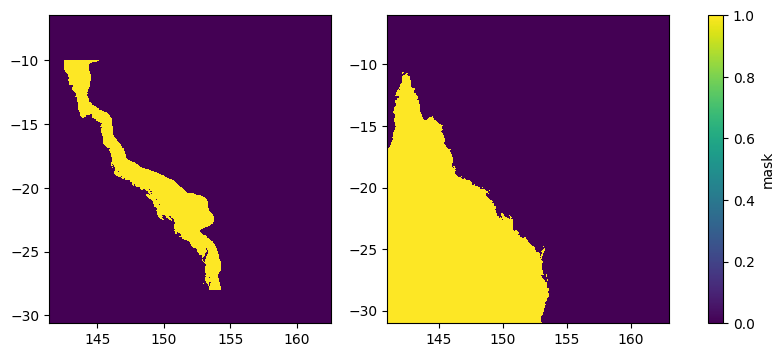

In [6]:
# GBR
shp_gbr50 = gpd.read_file('/g/data/p66/rj9627/UM_NS/create_SSflux/gbr50_region.shp')
gbr50_mask = regionmask.mask_geopandas(shp_gbr50, atmos_ds.longitude, atmos_ds.latitude)
gbr50_mask = xr.where(gbr50_mask == 0, 1, 0)

# NE Australia
land_mask = xr.open_dataset('/g/data/p66/rj9627/UM_NS/output/RRAP/NE_Aus_4km_land_mask.nc')
NEAus_mask = xr.where((land_mask.latitude <= -10.5) & (land_mask.longitude <= 153.6), land_mask.land_binary_mask, 0)
NEAus_mask.values[450:,200:] = 0 # Remove southern PNG

# Plot
fig, axs = plt.subplots(1,2, figsize=(10,4))
ax0 = axs[0].pcolormesh(gbr50_mask.longitude, gbr50_mask.latitude, gbr50_mask)
ax1 = axs[1].pcolormesh(NEAus_mask.longitude, NEAus_mask.latitude, NEAus_mask)
plt.colorbar(ax1, ax=axs[:]).set_label('mask');

### Plot atmospheric model output

Map of N3 ($cm^{-3}$)

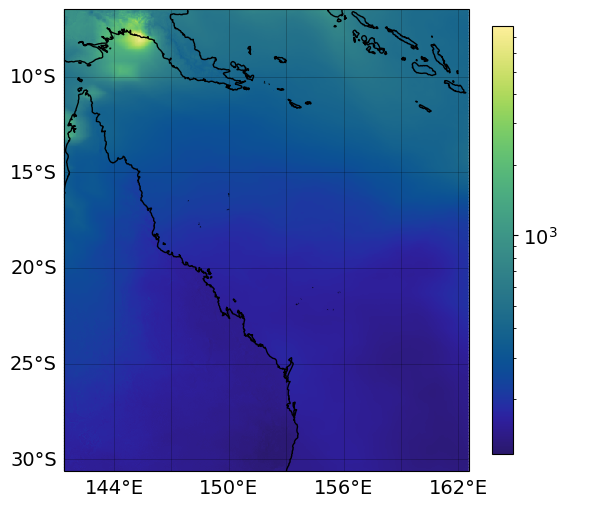

In [7]:
plot_map(atmos_ds['m01s38i437'].mean(dim='time', keep_attrs=True), atmos_ds.latitude, atmos_ds.longitude, cmocean.cm.haline, plt_log=True)

Time-series of N3 ($cm^{-3}$) at Heron Island

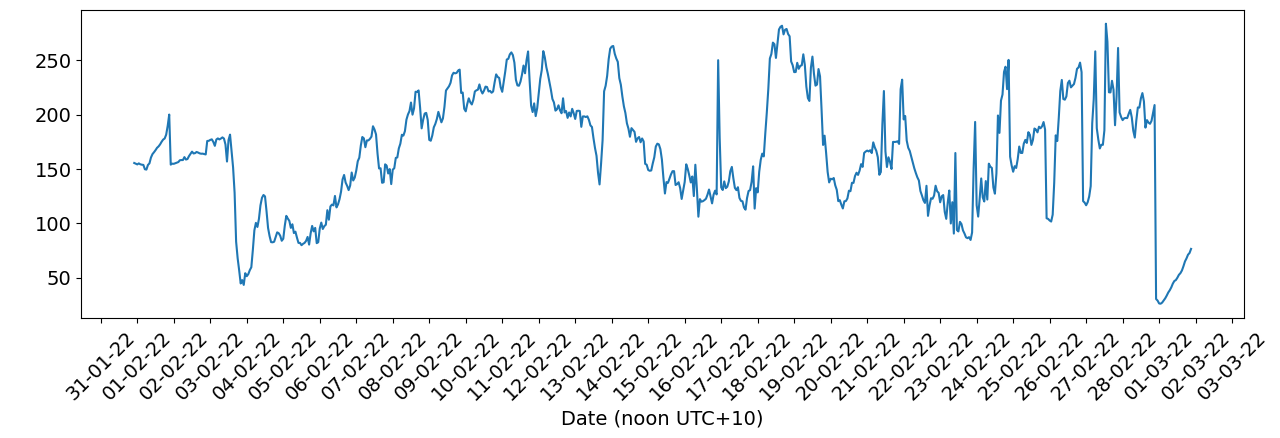

In [8]:
atmos_ds_Heron = get_model4coord(atmos_ds.copy(), -23.44, 151.91)
plot_tseries(atmos_ds_Heron['m01s38i437'])

Summary statistics - area means over the GBR

In [9]:
var_list = ['aerosol_salt_mass', # Aerosol sea salt mass (ug m-3)
            'Total_AOD',         # Aerosol optical depth (550 nm)
            'm01s38i437',        # Aerosol number concentration w. dry diameter > 3 nm (cm-3)
            'm01s16i004',        # Air temperature (K)
            'm01s01i202',        # Net surface downwelling short-wave radiation (W m-2)
            'WindSpeed']         # Wind speed calculated from U and V components (m s-1)
            
atmos_ds_gbr = xr.Dataset()
for ivar in var_list:
    atmos_ds_gbr[ivar] = xr.where(gbr50_mask == 1, atmos_ds[ivar], np.nan, keep_attrs=True)
atmos_ds_gbr = atmos_ds_gbr.mean(dim=['latitude','longitude'], skipna=True)

sum_stats(atmos_ds_gbr, var_list)

╒═══════════════════╤══════════════╤════════════╤═════════════╤═══════════╤═════════════════╕
│ Variable          │   No. points │       Mean │         Min │       Max │              SD │
╞═══════════════════╪══════════════╪════════════╪═════════════╪═══════════╪═════════════════╡
│ aerosol_salt_mass │          696 │  14.146    │   5.0929    │  29.772   │    28.2578      │
├───────────────────┼──────────────┼────────────┼─────────────┼───────────┼─────────────────┤
│ Total_AOD         │          696 │   0.127897 │   0.0713858 │   0.19961 │     0.000954577 │
├───────────────────┼──────────────┼────────────┼─────────────┼───────────┼─────────────────┤
│ m01s38i437        │          696 │ 236.255    │ 142.969     │ 337.146   │  1897.41        │
├───────────────────┼──────────────┼────────────┼─────────────┼───────────┼─────────────────┤
│ m01s16i004        │          696 │ 300.343    │ 299.3       │ 301.762   │     0.238672    │
├───────────────────┼──────────────┼────────────┼───────────

### Plot ocean model output

Map seawater temperature (C)

/jobfs/146121365.gadi-pbs/ipykernel_2016146/3359829082.py:32: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(ax_plt, fraction=0.046*im_ratio, orientation='vertical').set_label(label=plt_label)


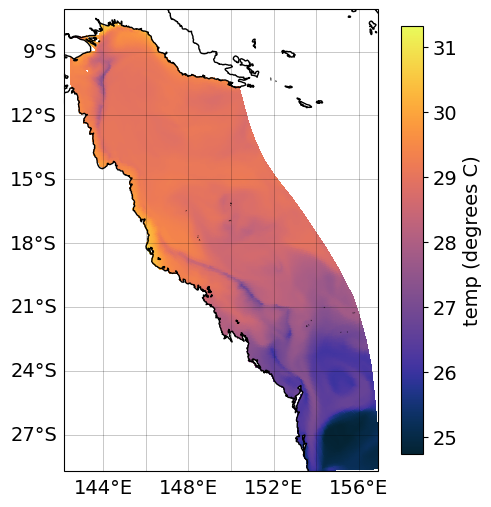

In [10]:
plot_map(ocean_ds['temp'].mean(dim='time', keep_attrs=True), ocean_ds.y_centre, ocean_ds.x_centre, cmocean.cm.thermal, plt_log=False)

Time-series of seawater temperature at Heron Island

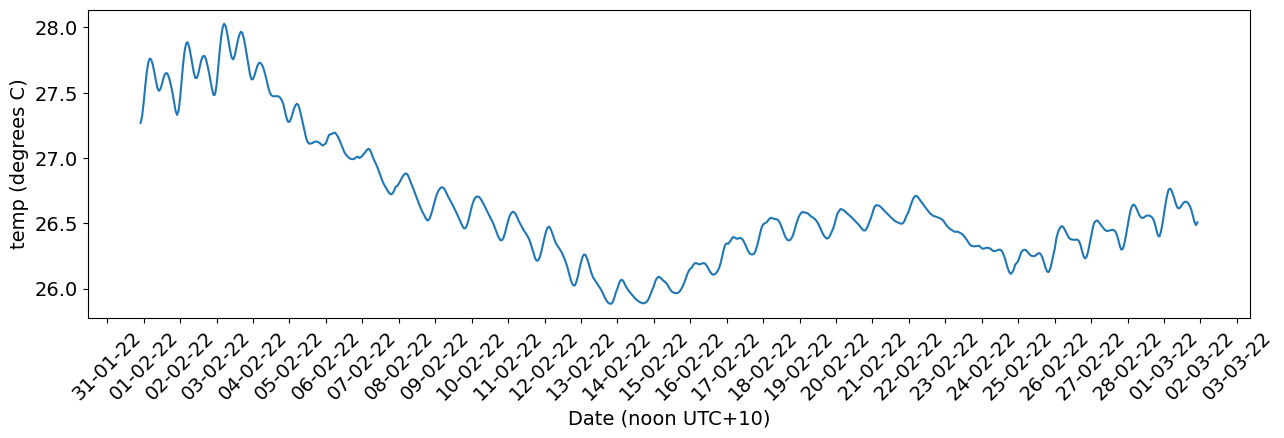

In [11]:
ocean_ds_Heron = get_model4coord(ocean_ds.copy(), -23.44, 151.91)
plot_tseries(ocean_ds_Heron['temp'])

Summary statistics - area means over the GBR

In [12]:
var_list = ['temp',      # Temperature (C)
            'salt',      # Salinity (PSU)
            'PAR',       # Photosynthetically active radiation (mol photons m-2 s-1)
            'CS_RO',     # Reactive oxygen concentration in coral symbionts (umol m-2)
            'CS_Chl',    # Coral symbiont chlorophyll concentration (mg m-2)
            'CS_bleach'] # Rate of coral symbiont expulsion (cells d-1)

# Create subset dataset with renamed lat/lon coordinates
ocean_ds_gbr = xr.Dataset()
ocean_ds_gbr['lat'] = ocean_ds['y_centre'].copy()
ocean_ds_gbr['lon'] = ocean_ds['x_centre'].copy()
for ivar in var_list:
    ocean_ds_gbr[ivar] = ocean_ds[ivar].copy()
    
# Regrid ocean data to atmos grid
src_grid = xr.merge([ocean_ds_gbr.lon, ocean_ds_gbr.lat])
tgt_grid = gbr50_mask.to_dataset()
regridder = xe.Regridder(src_grid, tgt_grid, method='bilinear')
ocean_ds_gbr = regridder(ocean_ds_gbr, output_chunks={'lat':len(tgt_grid.latitude), 'lon':len(tgt_grid.longitude)})

# Mask data
for ivar in var_list:
    ocean_ds_gbr[ivar] = xr.where(gbr50_mask==1, ocean_ds_gbr[ivar], np.nan, keep_attrs=True)
ocean_ds_gbr = ocean_ds_gbr.mean(dim=['latitude','longitude'], skipna=True)

sum_stats(ocean_ds_gbr, var_list)

╒════════════╤══════════════╤══════════════╤══════════════╤══════════════╤═════════════╕
│ Variable   │   No. points │         Mean │          Min │          Max │          SD │
╞════════════╪══════════════╪══════════════╪══════════════╪══════════════╪═════════════╡
│ temp       │          697 │ 28.2407      │ 27.8747      │ 29.0545      │ 0.0851535   │
├────────────┼──────────────┼──────────────┼──────────────┼──────────────┼─────────────┤
│ salt       │          697 │ 35.2006      │ 35.0908      │ 35.2631      │ 0.00289094  │
├────────────┼──────────────┼──────────────┼──────────────┼──────────────┼─────────────┤
│ PAR        │          697 │  0.000177765 │  5.52649e-12 │  0.000825141 │ 5.38582e-08 │
├────────────┼──────────────┼──────────────┼──────────────┼──────────────┼─────────────┤
│ CS_RO      │          697 │  6.28647e-08 │  5.02486e-08 │  7.05562e-08 │ 2.37425e-17 │
├────────────┼──────────────┼──────────────┼──────────────┼──────────────┼─────────────┤
│ CS_Chl     │       